# Question 2 — pairwise spike-train interactions

## Final answer: Not enough data / no differences

This notebook presents the prespecified analysis for the question:

> In which brain area are pairwise spike train interactions strongest at the 100 ms timescale?

The inferential unit is the mouse. Unit pairs are summarized within each mouse
and brain area before any group comparison. The expensive 17-mouse correlation
and surrogate analyses are **not recomputed**; this notebook loads their saved
CSV, JSON, and PNG outputs.

### Notebook roadmap

1. Load one mouse's provided spike times and cluster/area labels as a Pynapple
   `TsGroup`; no spike detection is performed.
2. Verify Pynapple's 100 ms counts against a transparent NumPy implementation.
3. Offer an optional Pynaviz spike-raster inspection.
4. Explain the surrogate-corrected pairwise interaction measure.
5. Load and plot the saved 17-mouse primary results, including 95% bootstrap CIs.
6. Show unit-count, timescale, and trial-only robustness checks and apply the
   prespecified multiple-choice decision rule.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
from IPython.display import Image, Markdown, display

project = Path.cwd()
if not (project / 'run_q2_interactions.py').exists():
    project = project.parent
sys.path.insert(0, str(project))

from run_q2_interactions import (
    Config,
    count_matrix,
    eligible_group,
    load_mouse_spikes,
    numpy_count_reference,
)

data_dir = project / 'data'
results_dir = project / 'results' / 'q2_interactions'
cfg = Config()
from importlib.metadata import version
print(f'Python {sys.version.split()[0]} | Pynapple {nap.__version__} | Pynaviz {version("pynaviz")}')

Python 3.11.9 | Pynapple 0.11.3 | Pynaviz 0.2.0


## Why Pynapple and Pynaviz?

`TsGroup` keeps each provided unit's timestamps together with its brain-area metadata and time support. `TsGroup.count` then creates the 100 ms count trains. No spike detection is performed: `spikes.npy` already contains spike times and `clusters.npy` assigns them to units. Pynaviz can interactively inspect the resulting `TsGroup`. The correlation, surrogate correction, and mouse-level statistics remain explicit NumPy/SciPy operations because Pynapple cross-correlograms answer a different, lag-dependent question.

In [ ]:
spikes_mouse1, duration_mouse1, qc_mouse1 = load_mouse_spikes(1, data_dir, cfg)
spikes_mouse1 = eligible_group(spikes_mouse1, cfg)
counts_nap, unit_ids_nap = count_matrix(spikes_mouse1, cfg.bin_s)
counts_np, unit_ids_np = numpy_count_reference(
    spikes_mouse1, duration_mouse1, cfg.bin_s
)

display(qc_mouse1.groupby('brain_area').agg(
    n_units=('unit_id', 'size'),
    median_rate_hz=('firing_rate_hz', 'median'),
    min_rate_hz=('firing_rate_hz', 'min'),
    max_rate_hz=('firing_rate_hz', 'max'),
))
print(f'Count matrix: {counts_nap.shape[0]} units × {counts_nap.shape[1]} bins')
print('Pynapple/NumPy count parity:',
      np.array_equal(unit_ids_nap, unit_ids_np) and np.array_equal(counts_nap, counts_np))

  Index      rate    brain_area
-------  --------  ------------
    383   4.40091             1
    386   6.29741             1
    388   8.06112             1
    389   2.24865             1
    391   2.88967             1
    392   3.40446             1
    396  11.5506              1
    399   0.3029              1
    402  12.3173              1
    404   7.61467             1
    405   3.58918             1
    407  14.6802              1
    411   3.21585             1
    416   3.6238              1
    419   4.05742             1
    423   2.0881              1
    426   6.60987             1
    428  12.6244              1
    431   1.72282             1
    432   7.82118             1
    435   7.47769             1
    439  14.6426              1
    440   7.75225             1
    441  11.6321              1
    445  60.1979              1
    448   9.53326             1
    449  13.0675              1
    450  11.2367              1
    453  10.6562              1
    456 

In [ ]:
# Pynaviz is interactive and opens a GPU-backed viewer, so opt in locally.
RUN_PYNAVIZ = False
if RUN_PYNAVIZ:
    import pynaviz
    raster = pynaviz.PlotTsGroup(spikes_mouse1)
    raster.group_by('brain_area')
    raster.color_by('brain_area', vmin=1, vmax=3)
    raster.show()
else:
    print('Set RUN_PYNAVIZ=True to inspect the area-grouped spike raster interactively.')

Set RUN_PYNAVIZ=True to inspect the area-grouped spike raster interactively.


## Primary interaction measure and justifications

### Step-by-step pipeline:
1. **Firing rate thresholding**: Retain units firing at least 0.05 Hz over the whole recording.
2. **Binned spike counting**: Count spikes in non-overlapping 100 ms bins.
3. **Within-area pairwise correlations**: For every within-area unit pair, calculate Pearson's $r$ and take its absolute value $|r|$.
4. **Circular-shift surrogate correction**: Independently circular-shift every unit's count train by 10–90% of the recording, repeated 100 times, and compute the mean $|r|$ surrogate.
5. **Corrected interaction strength**: Subtract the mean surrogate $|r|$ from the observed $|r|$.
6. **Mouse-level averaging**: Average these corrected interaction strengths within each mouse and brain area.

### Pipeline Justifications:
- **0.05 Hz threshold**: Excludes extremely sparse units that produce highly noisy and unstable correlation estimates due to low spike counts.
- **100 ms bin size**: Captures spike-train correlations at the typical behavioral/integrative timescale of local neural circuits (100 ms), matching the question requirement.
- **Absolute value $|r|$**: Measures interaction strength regardless of direction (excitatory/positive vs. inhibitory/negative), preventing positive and negative interactions from cancelling each other out.
- **Circular-shift surrogates**: Corrects for false correlations caused by slow non-stationarities (e.g., slow drift in firing rates or common trial-level arousal changes) while preserving the exact spike-count auto-correlation structure of each unit.
- **Mouse-level aggregation**: Treating unit pairs as independent samples would violate statistical independence (since pairs share units and recording conditions). Summarizing at the mouse level keeps the sample size conservative ($N=17$ independent mice) and valid for paired non-parametric tests.

In [ ]:
mouse_results = pd.read_csv(results_dir / 'primary_mouse_results.csv')
summary = pd.read_csv(results_dir / 'summary.csv')
tests = json.loads((results_dir / 'statistical_tests.json').read_text())

display(summary)
display(pd.DataFrame(tests['primary']['pairwise']))
print('Friedman p =', tests['primary']['friedman_p'])

,brain_area,candidate,mean,median,ci95_low,ci95_high,n_mice,metric
0,1,Brain area 1,0.039730,0.038379,0.033905,0.045840,17,mean_corrected_absolute_r
1,2,Brain area 2,0.076357,0.058848,0.056639,0.099604,17,mean_corrected_absolute_r
2,3,Brain area 3,0.076166,0.070626,0.061341,0.090507,17,mean_corrected_absolute_r


,left_area,right_area,mean_difference,median_difference,left_wins,right_wins,p_raw,p_holm
0,1,2,-0.036627,-0.026309,3,14,0.002090,0.004181
1,1,3,-0.036435,-0.033813,2,15,0.001343,0.004028
2,2,3,0.000192,-0.005488,8,9,0.644135,0.644135


Friedman p = 0.001642124077605926


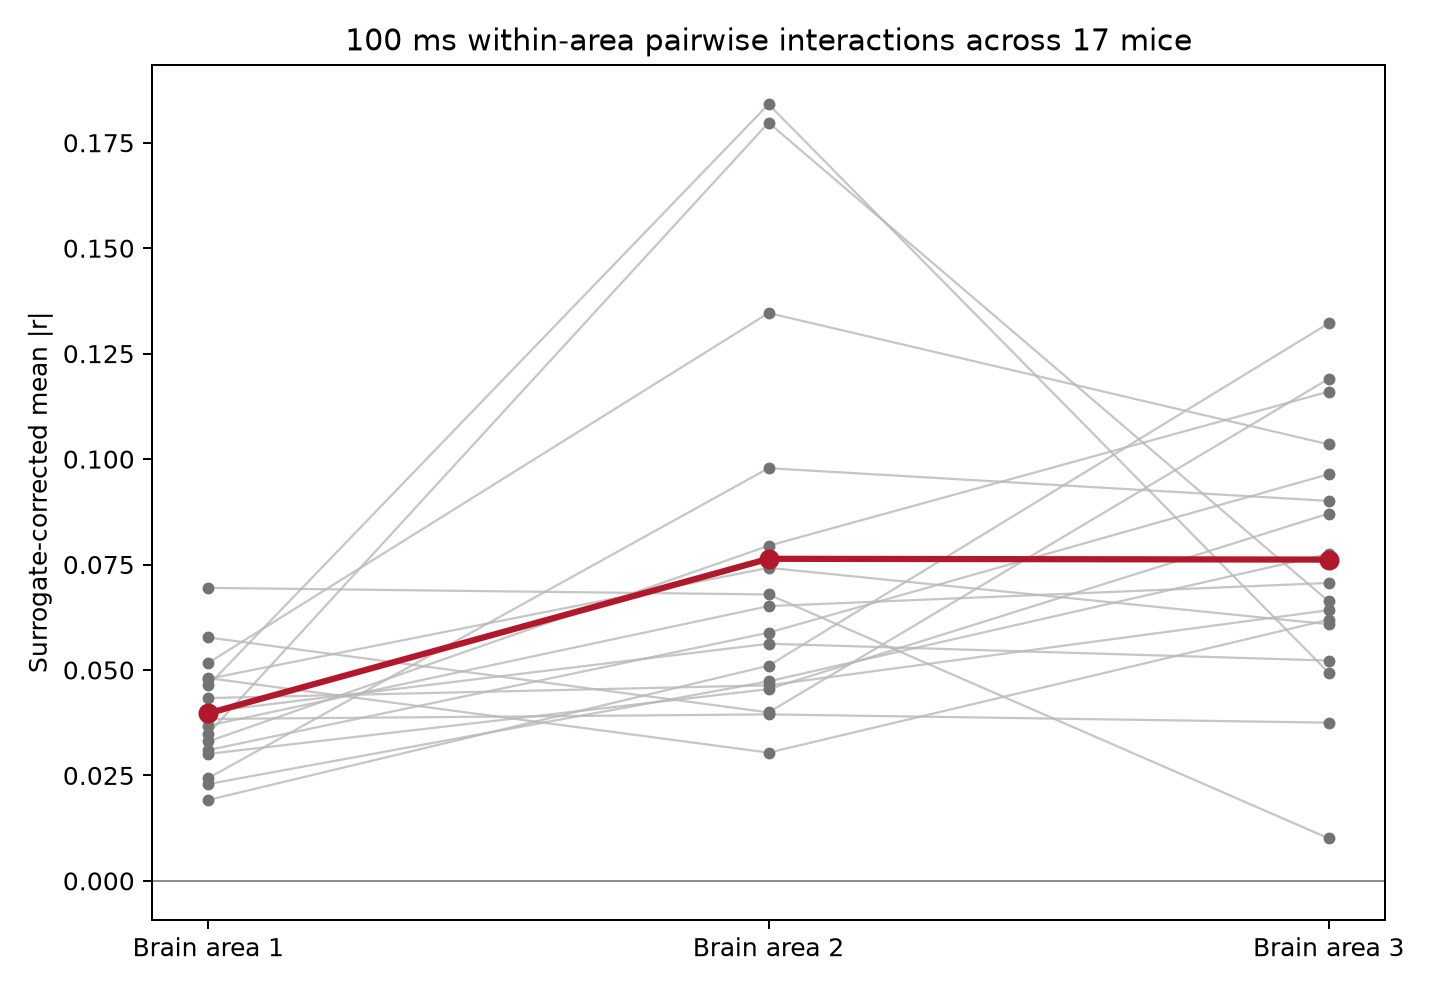

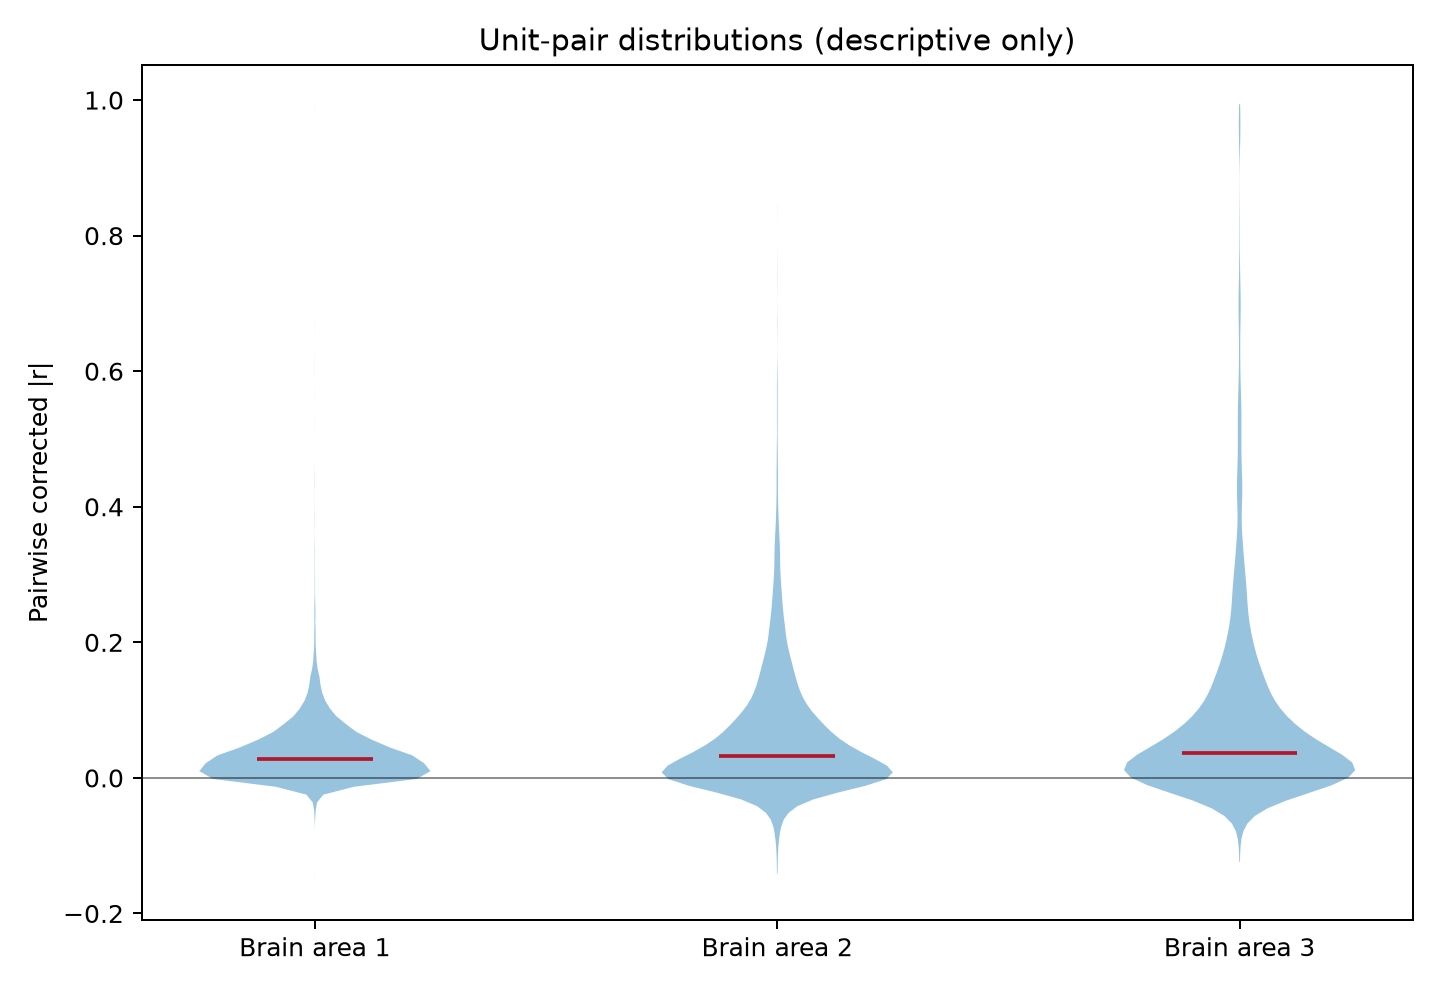

In [ ]:
display(Image(filename=str(results_dir / 'paired_mouse_interactions.png')))
display(Image(filename=str(results_dir / 'pair_distributions.png')))

The pair-distribution plot is descriptive only. Treating every pair as independent would inflate the sample size because pairs from the same mouse share units and recording conditions.

## Robustness checks

Area recordings contain different numbers of units. The equalized analysis repeatedly samples the same mouse-specific number of units from every area before averaging pair interactions. Additional exploratory sensitivity analyses use 50 ms and 200 ms bins and restrict the 100 ms analysis to task trials. These checks use 20 deterministic surrogates each; the answer-defining primary analysis uses 100.

In [ ]:
equalized = pd.read_csv(results_dir / 'unit_equalized_results.csv')
sensitivity = pd.read_csv(results_dir / 'sensitivity_results.csv')

display(equalized.groupby('brain_area')['mean_corrected_absolute_r'].agg(['mean', 'median']))
display(sensitivity)
print('Equalized answer:', tests['unit_equalized']['multiple_choice_answer'])

,mean,median
brain_area,,
1,0.039932,0.038343
2,0.076372,0.058717
3,0.076274,0.070867


,scope,bin_ms,area_1_mean,area_2_mean,area_3_mean,friedman_p,largest_mean_area,multiple_choice_answer,n_surrogates
0,whole_recording,50,0.029193,0.055675,0.066553,0.000040,3,Not enough data / no significant differences,20
1,whole_recording,200,0.052140,0.092335,0.084394,0.056003,2,Not enough data / no significant differences,20
2,task_trials,100,0.039632,0.081239,0.078048,0.000506,2,Not enough data / no significant differences,20


Equalized answer: Not enough data / no significant differences


## Multiple-choice decision rule

The primary omnibus comparison is a Friedman test across the three paired area measurements. Pairwise follow-ups use two-sided Wilcoxon signed-rank tests with Holm correction. An area is selected only if it has the largest mean **and** significantly exceeds both alternatives after correction. A significant omnibus test alone does not establish a unique strongest area.

In [ ]:
answer = tests['primary']['multiple_choice_answer']
display(Markdown(f'### Answer to Question 2: {answer}'))

### Answer to Question 2: Not enough data / no significant differences